In [2]:
import pandas as pd                                                                        # dataframe library
import numpy as np                                                                         # numerical operations library
import matplotlib.pyplot as plt                                                            # plotting library 
import seaborn as sns                                                                      # statistical data visualization library
import warnings                                                                            # to ignore warnings

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')                                                    # clean white grid background
pd.set_option('display.max_columns', 100)                                                  # show all columns in prints
warnings.filterwarnings('ignore')                                                          # hide all warnings so output is clean
pd.set_option('display.float_format', '{:.4f}'.format)                                       # 4 decimal places everywhere


In [4]:
#Load main training data
app_train = pd.read_csv('../Data/raw/application_train.csv')                               # read training data
app_test = pd.read_csv('../Data/raw/application_test.csv')                                 # read testing data

In [5]:
#Basic dimentions summary
print(f'Training data shape: {app_train.shape}')                                                  # 307,511 rows, 122 columns
print(f'Testing data shape: {app_test.shape}')                                                    # 487,44 rows,121 columns (same as train but without target column)
print(f"target column not present in test data: {set(app_train.columns) - set(app_test.columns)}") # target column not present in test data

Training data shape: (307511, 122)
Testing data shape: (48744, 121)
target column not present in test data: {'TARGET'}


In [6]:
#Target distribution
print("Target distribution:",app_train['TARGET'].value_counts())    # counts raw defaulters vs non-defaulters, 91.92% non-default, 8.08% default

Target distribution: TARGET
0    282686
1     24825
Name: count, dtype: int64


In [7]:
# Data Types Summary
print(app_train.dtypes.value_counts())                               # shows how many columns are float, int, and object (string)
                                                                     # 65 float, 41 int, 16 object (categorical) columns in training data, here object needs to be encoded before modeling, int and float can be used as is. Same for test data.

float64    65
int64      41
object     16
Name: count, dtype: int64


In [8]:
#Memory usage summary
print(f"Training data memory usage:{app_train.memory_usage().sum() / 1e6: .1f} MB")   # 300.1 MB

Training data memory usage: 300.1 MB



application_train: 67 columns with missing values
                                            column  missing_counts  \
COMMONAREA_MEDI                    COMMONAREA_MEDI          214865   
COMMONAREA_AVG                      COMMONAREA_AVG          214865   
COMMONAREA_MODE                    COMMONAREA_MODE          214865   
NONLIVINGAPARTMENTS_MODE  NONLIVINGAPARTMENTS_MODE          213514   
NONLIVINGAPARTMENTS_AVG    NONLIVINGAPARTMENTS_AVG          213514   
NONLIVINGAPARTMENTS_MEDI  NONLIVINGAPARTMENTS_MEDI          213514   
FONDKAPREMONT_MODE              FONDKAPREMONT_MODE          210295   
LIVINGAPARTMENTS_MODE        LIVINGAPARTMENTS_MODE          210199   
LIVINGAPARTMENTS_AVG          LIVINGAPARTMENTS_AVG          210199   
LIVINGAPARTMENTS_MEDI        LIVINGAPARTMENTS_MEDI          210199   
FLOORSMIN_AVG                        FLOORSMIN_AVG          208642   
FLOORSMIN_MODE                      FLOORSMIN_MODE          208642   
FLOORSMIN_MEDI                      FLO

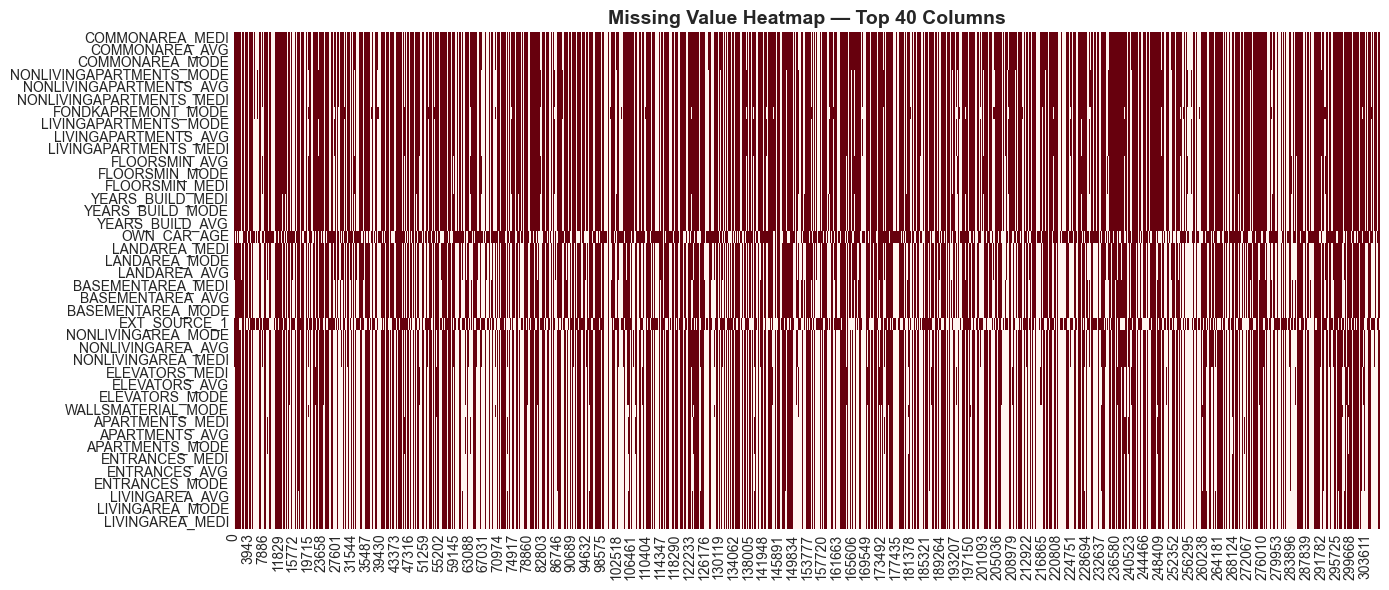

In [9]:
#MISSING VALUES SUMMARY
def analyze_missing(df,name="Dataframe"):
    missing= pd.DataFrame({'column':df.columns,'missing_counts':df.isnull().sum(),'missing_pct':(df.isnull().sum()/len(df)*100),
                           'dtype':df.dtypes.values}).sort_values('missing_pct',ascending=False)                # shows missing values count and percentage for each column, sorted by percentage, also shows data type of each column, this is important for deciding how to handle missing values in each column.
    missing=missing[missing['missing_counts']>0]                                                                # filter to only columns with missing values, this is important for focusing on the columns that need attention, if there are no missing values in a column, we can ignore it for missing value handling.
    print(f'\n{name}: {len(missing)} columns with missing values')                                              # print number of columns with missing values, this gives an overview of how many columns need attention for missing value handling.
    print((missing.head(30)))                                                                                   # print top 30 columns with missing values, this gives a detailed view of which columns have the most missing values and their data types, this is important for prioritizing which columns to handle first based on the percentage of missing values and their data types.  
    return missing
missing_df=analyze_missing(app_train,"application_train")

#Visual missing value heatmap
fig, ax=plt.subplots(figsize=(14,6))                                                                             # wide figure for heatmap
cols_with_missing=missing_df[missing_df['missing_pct']> 0 ]['column'].values[:40]                               # top 40 worst
missing_matrix= app_train[cols_with_missing].isnull().astype(int)                                                # 1=missing 0=present
sns.heatmap(missing_matrix.T, cmap='Reds', cbar=False, ax=ax, yticklabels=True)                                  # red = missing
ax.set_title('Missing Value Heatmap — Top 40 Columns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/missing_heatmap.png', dpi=150)                                                              # save to reports folder
plt.show()

In [10]:
#Columns to DROP (>60% missing — not enough signal)

cols_to_drop=missing_df[missing_df['missing_pct']>60]['column'].tolist()
print(f"\n Columns to drop (>60% missing) : {len(cols_to_drop)}")
print(cols_to_drop)

# Example: COMMONAREA_AVG, NONLIVINGAPARTMENTS_AVG, etc.
# Business explanation for key missing columns 
# EXT_SOURCE_1: 56% missing ® external credit score from bureau 1 (not all clients scored)
# EXT_SOURCE_2: 0.2% missing ® most important external score
# EXT_SOURCE_3: 19% missing ® third bureau score
# OWN_CAR_AGE: 65% missing ® only filled if FLAG_OWN_CAR = 'Y'
# OCCUPATION_TYPE: 31% missing ® applicants who didn't disclose occupation


 Columns to drop (>60% missing) : 17
['COMMONAREA_MEDI', 'COMMONAREA_AVG', 'COMMONAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAPARTMENTS_MEDI', 'FONDKAPREMONT_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAPARTMENTS_AVG', 'LIVINGAPARTMENTS_MEDI', 'FLOORSMIN_AVG', 'FLOORSMIN_MODE', 'FLOORSMIN_MEDI', 'YEARS_BUILD_MEDI', 'YEARS_BUILD_MODE', 'YEARS_BUILD_AVG', 'OWN_CAR_AGE']


DATA ANALYSIS

Before diving into specific business metrics, I am utilizing ydata_profiling on a 10,000-row sample to generate a high-level baseline. This allows for rapid identification of missing value matrices, global correlations, and hidden dataset warnings. From these automated insights, I will build targeted, custom visualizations below to deeply analyze the specific features tied to default risk.

Summarize dataset:  15%|█▌        | 714/4619 [02:03<11:14,  5.79it/s, scatter FLOORSMAX_MEDI, DAYS_EMPLOYED]                           


KeyboardInterrupt: 

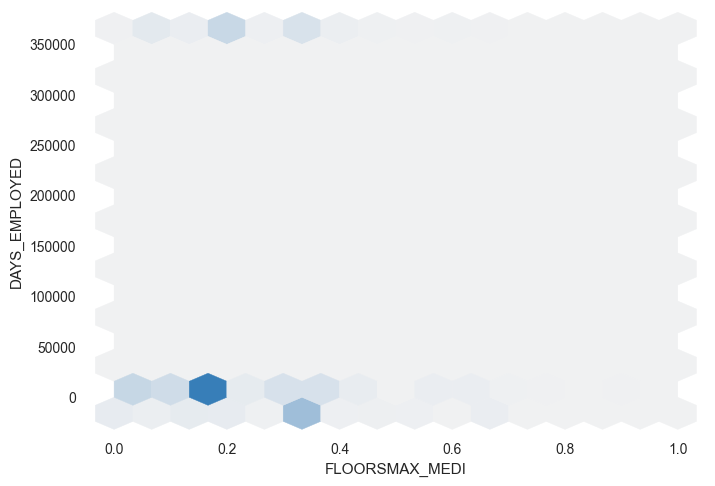

In [11]:
#ydata_profiling (formerly known as pandas_profiling) is an incredibly powerful library that essentially puts the initial phases of data exploration on autopilot.

from ydata_profiling import ProfileReport

#FULL Automated EDA (created 122X122 relations which is too big to analyse,it crashes the system)

profile= ProfileReport( app_train.sample(10000,random_state=42),title="Home Credit - Application Train EDA", minimal=False,     #sampling 10000 rows rather than all to save time and crashing, also random state =42 make sure every time i run the output remain the same by not not changing sample every time.and minimal=False tell dont take shortcut and do heavy statistics.
                        correlations={'pearson':{'calculate':True}},missing_diagrams={'heatmap':True},explorative=True
                        )

profile.to_file('reports/eda_profile.html')
print("Profile saved --> open reports/eda_profile.html in browser")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 28.66it/s]


Lightweight Profile saved --> open reports/eda_profile_fast.html in browser


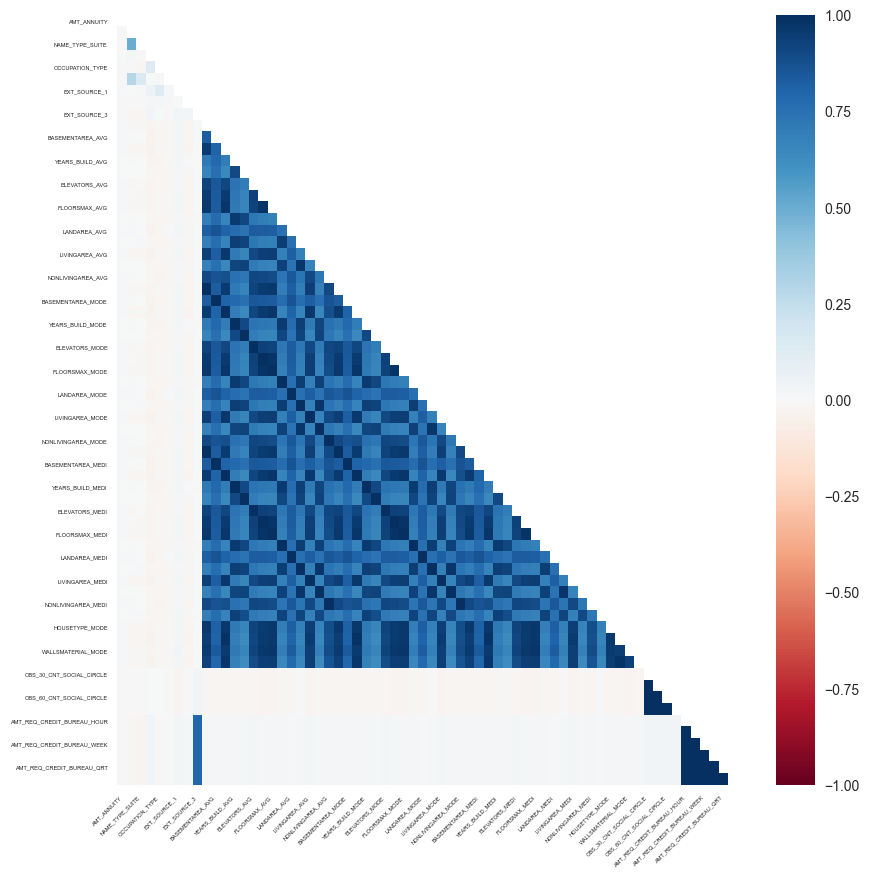

In [ ]:
from ydata_profiling import ProfileReport

# Lightweight Automated EDA - Turning off heavy interactions
profile = ProfileReport(
    app_train.sample(10000, random_state=42), 
    title="Home Credit - Fast EDA",
    minimal=False, 
    explorative=False,          # 1. Turn off heavy explorative mode
    interactions=None,          # 2. Kill the 10,000 interaction scatter plots
    correlations={'pearson': {'calculate': True}},
    missing_diagrams={'heatmap': True}
)

profile.to_file('reports/eda_profile_fast.html')
print("Lightweight Profile saved --> open reports/eda_profile_fast.html in browser")

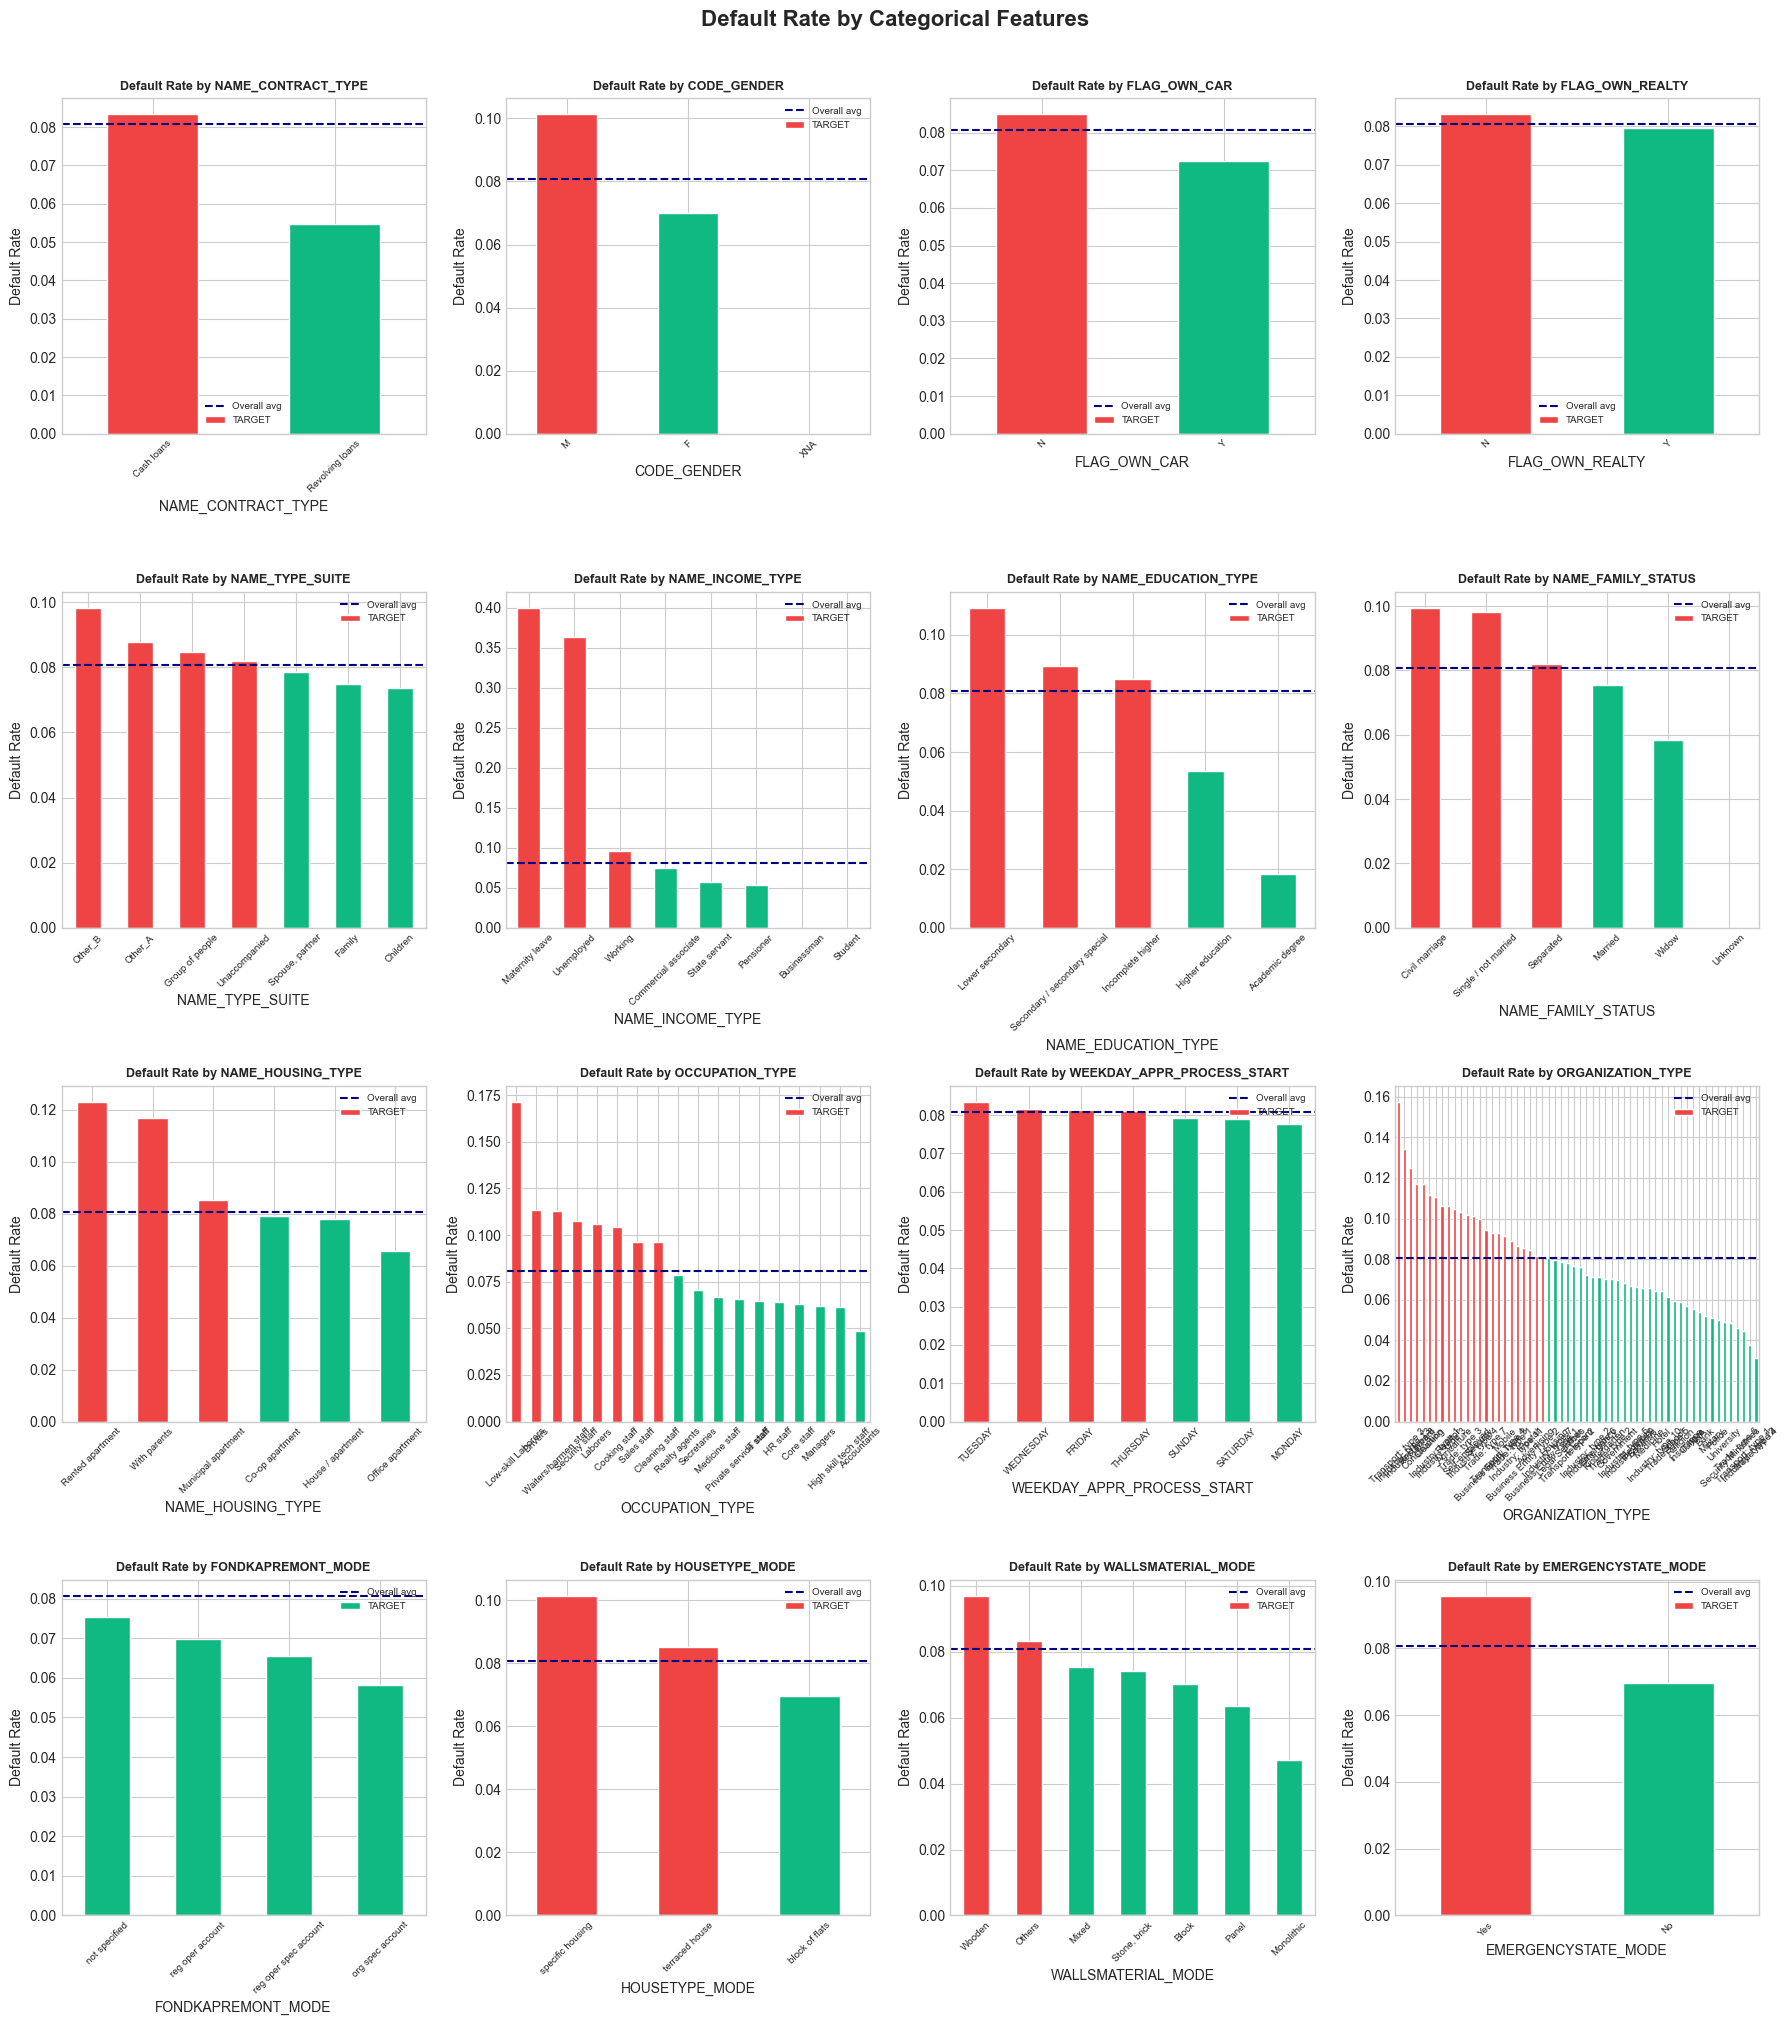

In [ ]:
#Default rate by categorical features

categorical_cols=['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE',
                   'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
                    'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']

fig, axes = plt.subplots(4,4, figsize=(18,20))              # 4 rows × 4 cols grid
axes= axes.ravel()                                           # flatten 2D array so we can index with one number
for i, col in enumerate(categorical_cols):
    default_rate= app_train.groupby(col)['TARGET'].mean().sort_values(ascending=False)                    # mean of TARGET per category = default rate per category
    
    # red bar if above average default rate, green if below
    colors_bar = ['#EF4444' if x> app_train['TARGET'].mean() else '#10B981' for x in default_rate.values]

    default_rate.plot(kind='bar', ax=axes[i], color=colors_bar, edgecolor='white')
    axes[i].set_title(f'Default Rate by {col}', fontweight='bold', fontsize=9)

     # dashed horizontal line at the overall average default rate (8.1%)

    axes[i].axhline(app_train['TARGET'].mean(), color='navy', linestyle='--',
    linewidth=1.5, label='Overall avg')
    axes[i].set_ylabel('Default Rate')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].legend(fontsize=7)
plt.suptitle('Default Rate by Categorical Features', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/default_by_category.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
#KEY FINFINGS TO NOTE
print("Key default rate findings:")
print(f" Males default at: {app_train[app_train['CODE_GENDER']=='M']['TARGET'].mean():.3f}")
print(f" Females default at: {app_train[app_train['CODE_GENDER']=='F']['TARGET'].mean():.3f}")
edu_default = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by Education:\n{edu_default}")

inc_default = app_train.groupby('NAME_INCOME_TYPE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by Income Type:\n{inc_default}")

occupation_default = app_train.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by Occuptation Type:\n{inc_default}")

occupation_default = app_train.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by Occuptation Type:\n{inc_default}")

name_type_default = app_train.groupby('NAME_TYPE_SUITE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by name Type:\n{inc_default}")

name_house_default = app_train.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().sort_values(ascending=False)
print(f"\nDefault by name house Type:\n{inc_default}")

Key default rate findings:
 Males default at: 0.101
 Females default at: 0.070

Default by Education:
NAME_EDUCATION_TYPE
Lower secondary                 0.1093
Secondary / secondary special   0.0894
Incomplete higher               0.0848
Higher education                0.0536
Academic degree                 0.0183
Name: TARGET, dtype: float64

Default by Income Type:
NAME_INCOME_TYPE
Maternity leave        0.4000
Unemployed             0.3636
Working                0.0959
Commercial associate   0.0748
State servant          0.0575
Pensioner              0.0539
Businessman            0.0000
Student                0.0000
Name: TARGET, dtype: float64

Default by Occuptation Type:
NAME_INCOME_TYPE
Maternity leave        0.4000
Unemployed             0.3636
Working                0.0959
Commercial associate   0.0748
State servant          0.0575
Pensioner              0.0539
Businessman            0.0000
Student                0.0000
Name: TARGET, dtype: float64

Default by Occuptation Typ

Top 15 NEGATIVE correlations with TARGET:
EXT_SOURCE_3                 -0.1789
EXT_SOURCE_2                 -0.1605
EXT_SOURCE_1                 -0.1553
DAYS_EMPLOYED                -0.0449
FLOORSMAX_AVG                -0.0440
FLOORSMAX_MEDI               -0.0438
FLOORSMAX_MODE               -0.0432
AMT_GOODS_PRICE              -0.0396
REGION_POPULATION_RELATIVE   -0.0372
ELEVATORS_AVG                -0.0342
ELEVATORS_MEDI               -0.0339
FLOORSMIN_AVG                -0.0336
FLOORSMIN_MEDI               -0.0334
LIVINGAREA_AVG               -0.0330
LIVINGAREA_MEDI              -0.0327
Name: TARGET, dtype: float64
Top 15 POSITIVE correlations with TARGET:
FLAG_WORK_PHONE               0.0285
DEF_60_CNT_SOCIAL_CIRCLE      0.0313
DEF_30_CNT_SOCIAL_CIRCLE      0.0322
LIVE_CITY_NOT_WORK_CITY       0.0325
OWN_CAR_AGE                   0.0376
DAYS_REGISTRATION             0.0420
FLAG_DOCUMENT_3               0.0443
REG_CITY_NOT_LIVE_CITY        0.0444
FLAG_EMP_PHONE                0.0460

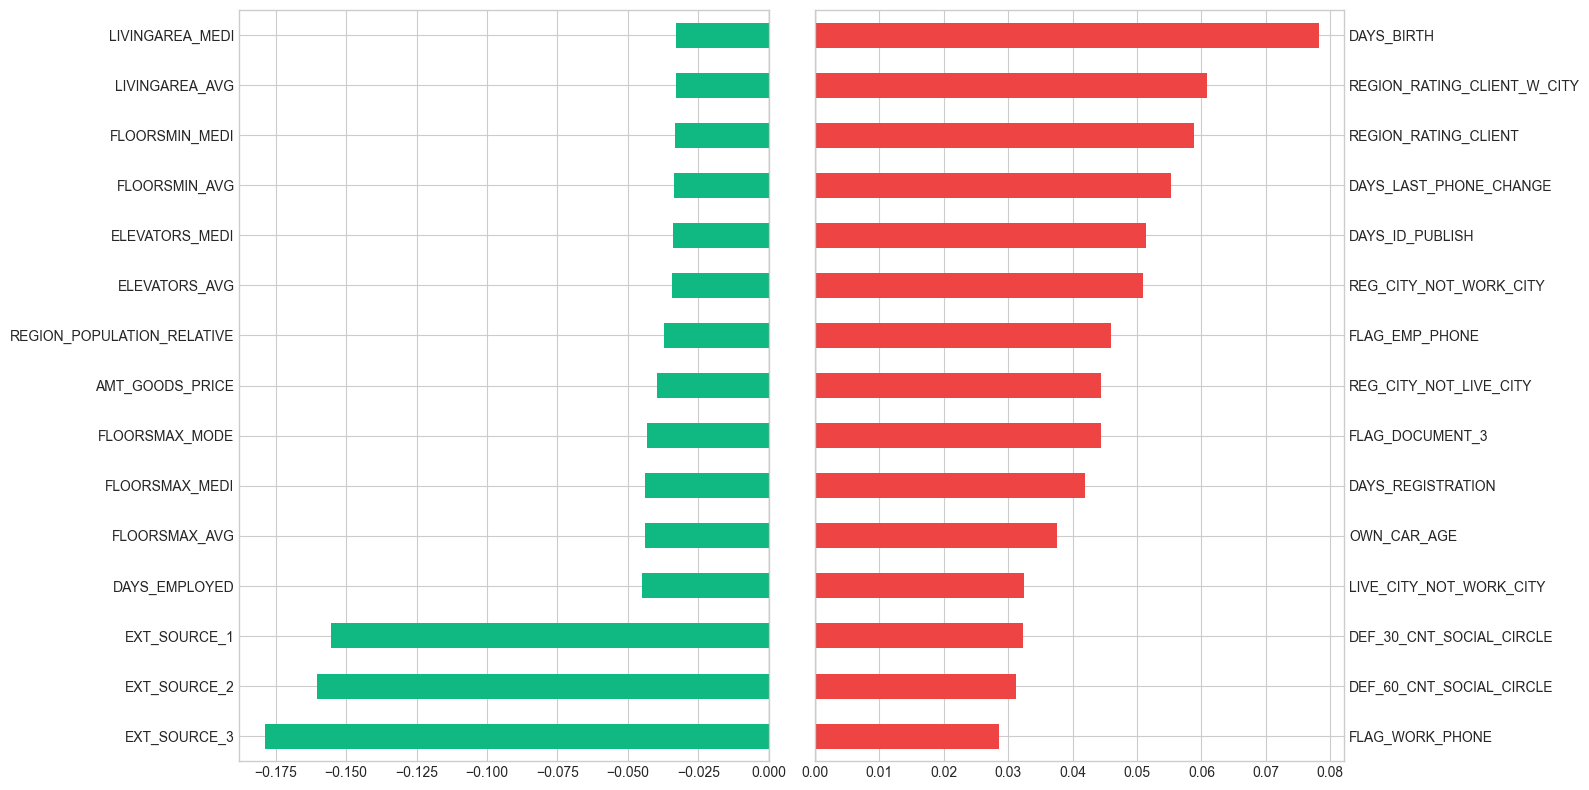

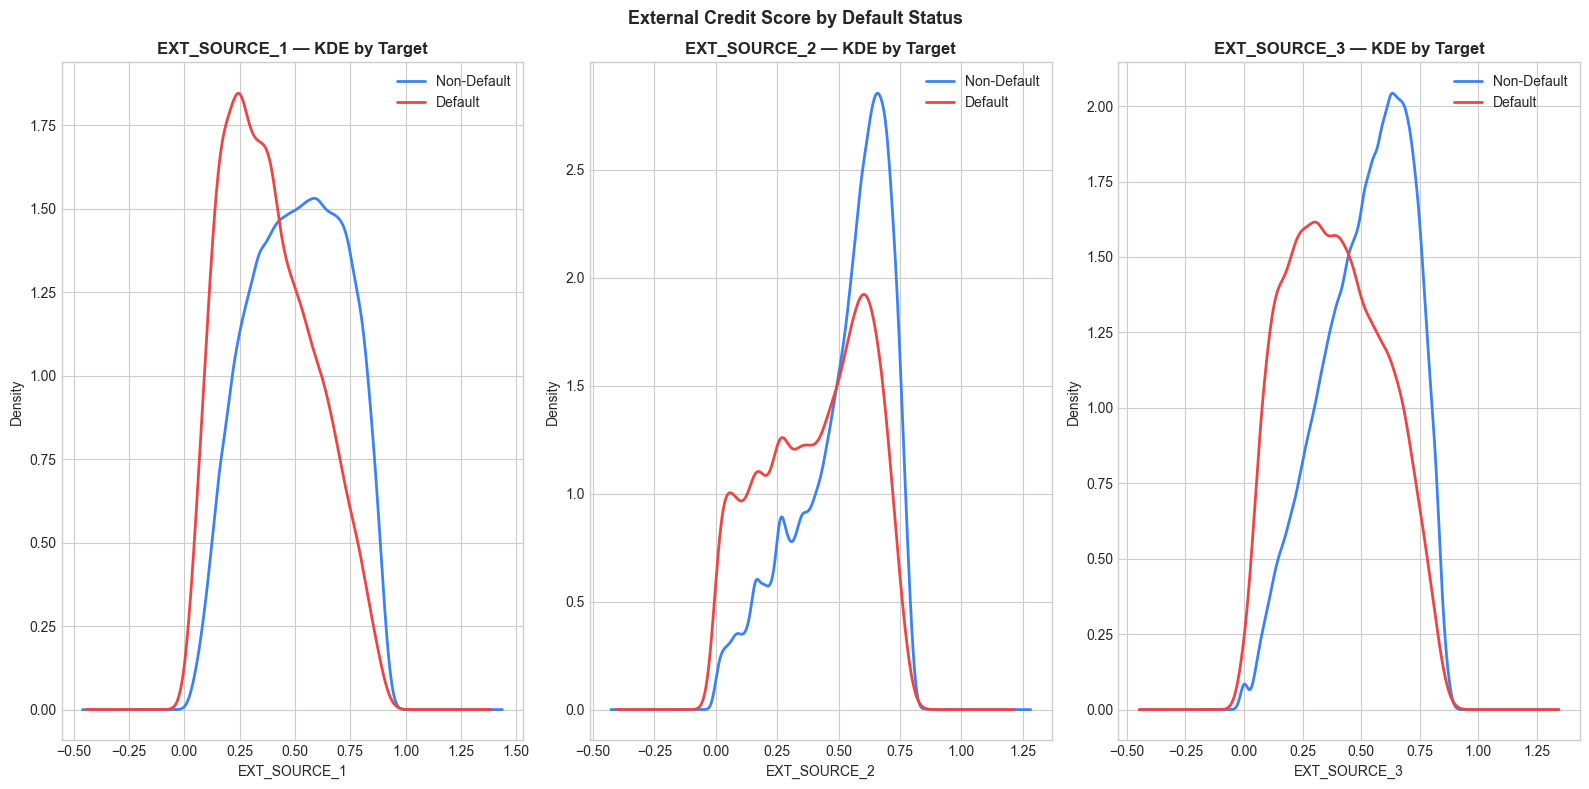

In [ ]:
#Correlation with TARGET

numeric_df=app_train.select_dtypes(include=[np.number])                             # keep only numeric columns so we can compute correlation                             
correlations=numeric_df.corr()['TARGET'].drop('TARGET').sort_values()               # Pearson correlation of every column against TARGET and also removing Target as it will correlate itself giving value 1          


print("Top 15 NEGATIVE correlations with TARGET:")
print(correlations.head(15))
print("Top 15 POSITIVE correlations with TARGET:")
print(correlations.tail(15))

# EXT_SOURCE_3, EXT_SOURCE_2, EXT_SOURCE_1 ,i.e. dxternal sources (higher score = less risky)are most negatively correlated with TARGET
# DAYS_BIRTH(older = less risky),REGION_RATING_CLIENT_W_CITY, REGION_RATING_CLIENT are most postively correlated with TARGET

fig, axes = plt.subplots(1,2, figsize=(16,8))
#NEGATIVE CORRELATION
correlations.head(15).plot(kind="barh",ax=axes[0],color='#10B981')                # green bars = features that reduce default probability when high
axes[0].axvline(0,color='black',linewidth=0.8)                                      # zero reference line

#POSITIVE CORRELATION
correlations.tail(15).plot(kind='barh',ax=axes[1],color='#EF4444')
axes[1].axvline(0,color='black',linewidth=0.8)
axes[1].yaxis.tick_right()

plt.tight_layout()                                                                  # Tried to bring both the table close

plt.savefig('reports/correlations_with_target.png', dpi=150)
plt.show()


#EXT_SOURCE deep dive - most important predictors
fig, axes = plt.subplots(1,3, figsize=(16,8))

for i, col in enumerate(['EXT_SOURCE_1',"EXT_SOURCE_2","EXT_SOURCE_3"]):
    for target, color ,label in [(0,'#3B82F6','Non-Default'),(1,'#EF4444','Default')]:
        app_train[app_train['TARGET']==target][col].dropna().plot.kde(ax=axes[i], color=color, label=label, linewidth=2)
        axes[i].set_title(f'{col} — KDE by Target', fontweight='bold')
        axes[i].legend(); axes[i].set_xlabel(col)

plt.suptitle('External Credit Score by Default Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/ext_source_distribution.png',dpi=15)
plt.show()

# Lower EXT_SOURCE scores ® significantly higher default probability

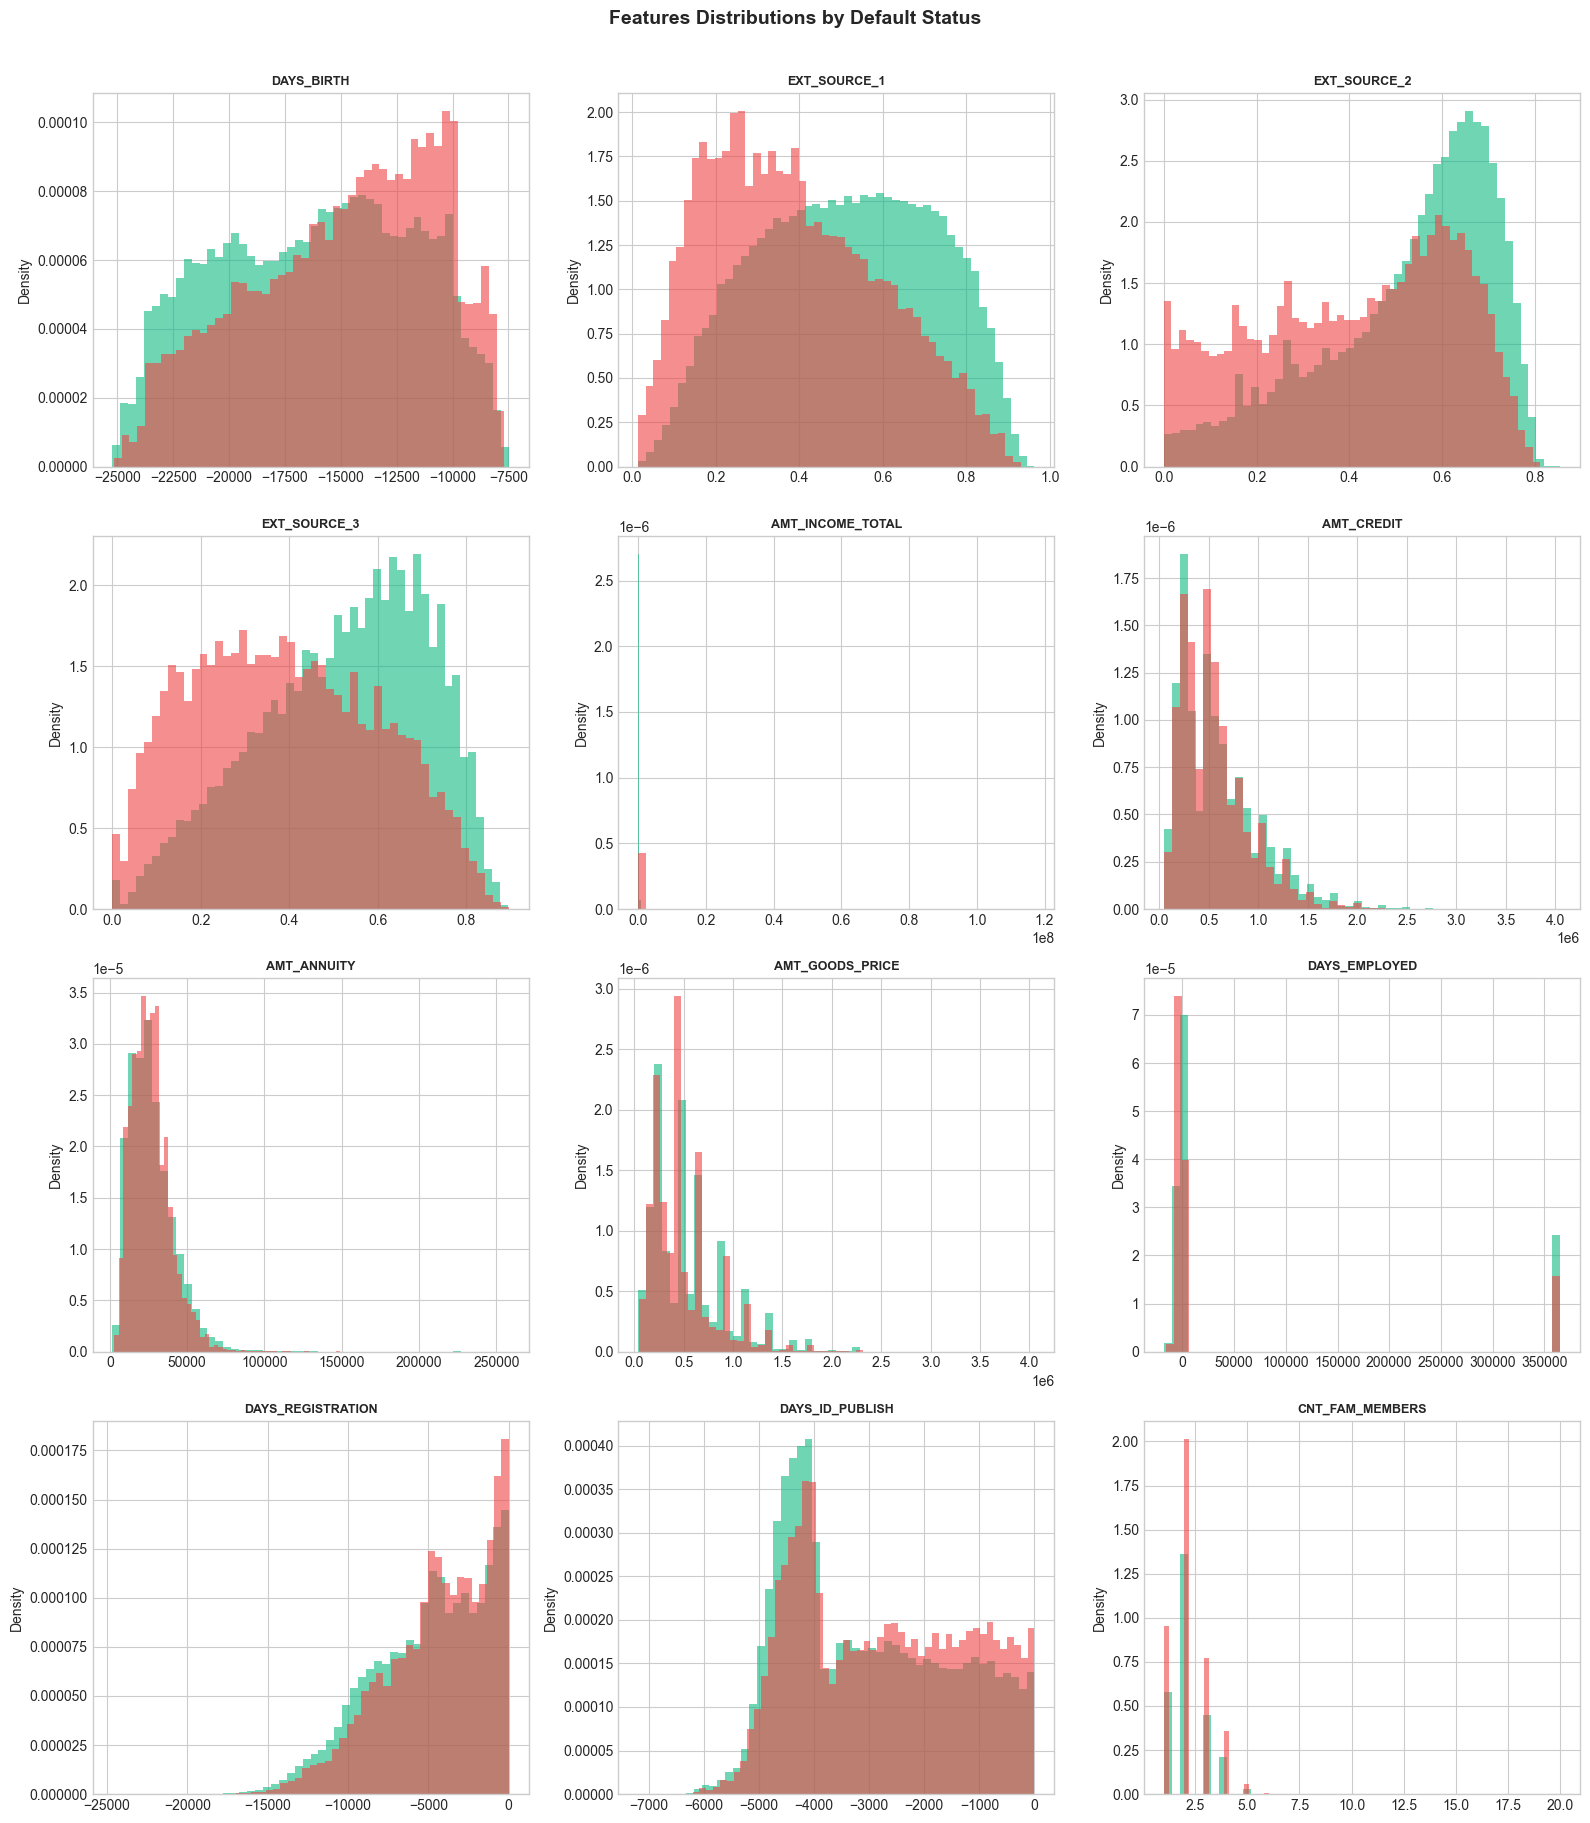

In [ ]:
#Most Important Numeric Features
key_numeric=['DAYS_BIRTH','EXT_SOURCE_1','EXT_SOURCE_2',"EXT_SOURCE_3","AMT_INCOME_TOTAL","AMT_CREDIT","AMT_ANNUITY","AMT_GOODS_PRICE","DAYS_EMPLOYED","DAYS_REGISTRATION","DAYS_ID_PUBLISH","CNT_FAM_MEMBERS"]

fig, axes =plt.subplots(4,3, figsize=(16,18))
axes= axes.ravel()                                                                      # Flatten the 2D grid so we can loop through it easily

for i, col in enumerate(key_numeric):

    # Loop through both target classes (0 and 1) to overlay their distributions

    for target,color, label in[(0,'#10B981','Non-Default'),(1,"#EF4444","Default")]:

        # Grab the specific column, filter by target, and drop missing values so the plot doesn't crash
        subset=app_train[app_train["TARGET"]==target][col].dropna()

        # We use a histogram with density=True instead of a KDE plot because 
        # it renders significantly faster on large datasets like this one
        axes[i].hist(subset,bins=50,alpha=0.6,color=color,label=label,density=True)

        # Formatting each individual subplot
        axes[i].set_title(f'{col}',fontweight='bold',fontsize=9)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Density')

# Final overarching layout formatting
plt.suptitle('Features Distributions by Default Status',fontsize=14, fontweight='bold',y=1.01)
plt.tight_layout()

# Save the chart to your reports folder before displaying it
plt.savefig('reports/numeric_distributions.png',dpi =150,bbox_inches='tight')
plt.show()







In [ ]:
#Critical: DAYS_EMPLOYED anamoly
print("Days_EMPLOYED unique values > 0 :")
print(app_train['DAYS_EMPLOYED'][app_train["DAYS_EMPLOYED"]>0].value_counts().head())
#The employment days count is in reverse order i.e. counting from today how many days. the person is employed so its negative.
#The massive value 365,243 is simply a database placeholder meaning "retired" or "pensioner," chosen because older banking systems couldn't handle blank spaces for unemployed applicants as 0 is reserved for 1st day employee. The code app_train['DAYS_EMPLOYED'] > 0 acts as a filter to instantly isolate and count these fake positive numbers so you can fix them before they break your machine learning model.

print(f"Rows with DAYS_EMPLOYED=365243:{(app_train['DAYS_EMPLOYED']==365243).sum()}")
print(f"Default rate for these rows:{app_train[app_train['DAYS_EMPLOYED']==365243]['TARGET'].mean():.4f}")

#AMT_INCOME_TOTAL Outliers
print(f"\n AMT_INCOME_TOTAL > 1M: {(app_train['AMT_INCOME_TOTAL']>1_000_000).sum()} rows")
print(app_train[app_train['AMT_INCOME_TOTAL'] > 1_000_000]["AMT_INCOME_TOTAL"].describe())

# Some incomes are 117M BRL — almost certainly data errors. Cap at 99th percentile.

Days_EMPLOYED unique values > 0 :
DAYS_EMPLOYED
365243    55374
Name: count, dtype: int64
Rows with DAYS_EMPLOYED=365243:55374
Default rate for these rows:0.0540

 AMT_INCOME_TOTAL > 1M: 250 rows
count         250.0000
mean      2156189.3100
std       7454048.1883
min       1001826.0000
25%       1125000.0000
50%       1350000.0000
75%       1788750.0000
max     117000000.0000
Name: AMT_INCOME_TOTAL, dtype: float64


EDA KEY FINDING :

(1) 8.1% default rate — severe imbalance requiring scale_pos_weight or SMOTE.


(2) EXT_SOURCE_2 is the single strongest predictor. 


(3) DAYS_EMPLOYED=365243 is a coded flag for retired persons, not actual employment days. 


(4) AMT_INCOME_TOTAL has extreme outliers (117MBRL) that need capping. 


(5) Applicants without cars or property default more.